# Verbesserte Referenzanalyse: Wine-Datensatz clustern

Dieses Notebook ist eine separate Orientierungsversion zu `clustering.ipynb`. Es setzt die Verbesserungen aus dem Review um, ohne das ursprüngliche Notebook zu verändern.

Die zentrale Idee: Clustering wird zunächst **unüberwacht** auf den Features durchgeführt. Die bekannte Zielspalte `target` wird nur zur späteren Einordnung und Validierung genutzt.

## tl;dr

- Der Wine-Datensatz ist für die Aufgabe geeignet: 178 Beobachtungen, 13 numerische Features, keine fehlenden Werte.
- Wegen sehr unterschiedlicher Wertebereiche werden die Features vor PCA und Clustering standardisiert.
- Die ersten zwei PCA-Komponenten erklären zusammen ungefähr 55 % der Varianz. Der 2D-Plot ist daher nützlich zur Visualisierung, aber keine vollständige Beschreibung der Daten.
- kMeans mit `k=3` passt gut zur sichtbaren Struktur und zu den bekannten Klassen. Die Wahl von `k=3` wird vorher mit Elbow- und Silhouette-Werten begründet.
- DBSCAN ist hier weniger passend: je nach `eps` entstehen viele kleine Cluster, Noise-Punkte oder zu wenige Cluster.
- Die bekannte Zielvariable wird erst am Ende zur Qualitätsprüfung genutzt, nicht zur Clusterbildung.

## Context & Methods

Die Aufgabenstellung fordert eine eigene explorative Datenanalyse mit numerischen Daten, PCA zur Visualisierung bzw. zum Verständnis und ein sinnvolles Clustering mit kMeans, DBSCAN oder einer passenden Methode.

In diesem Notebook wird der `Wine recognition Dataset` aus `sklearn.datasets` verwendet. Er enthält Laborwerte von Weinproben. Die Klassenlabels sind im Datensatz vorhanden, werden aber im Sinne des unüberwachten Lernens nicht zum Trainieren der Clusterverfahren verwendet.

### Key Assumptions

- Alle 13 Feature-Spalten sind numerisch und können gemeinsam skaliert werden.
- Die Zielspalte `target` ist nur eine externe Referenz zur Validierung.
- PCA mit zwei Komponenten dient primär der Visualisierung. Für eine robustere Clusterbildung wird zusätzlich auf allen 13 skalierten Features geclustert.
- Für reproduzierbare Ergebnisse werden feste `random_state`-Werte verwendet.

## Setup

In [1]:
import os

# Verhindert auf manchen macOS/Conda-Setups eine harmlose joblib-Warnung zur CPU-Erkennung.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")


## Data

### 1. Load Data

Der Datensatz wird direkt aus scikit-learn geladen. `features` enthält nur die Messwerte; `target` bleibt separat für spätere Validierung.

In [2]:
wine = load_wine(as_frame=True)
wine_frame = wine.frame.copy()

features = wine_frame.drop(columns="target")
target = wine_frame["target"].copy()
target_names = pd.Series(wine.target_names, name="target_name")

wine_frame.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 2. Validate Inputs

Vor dem Clustering wird geprüft, ob die Daten vollständig und numerisch sind. Außerdem wird die bekannte Klassenverteilung nur zur Einordnung betrachtet.

In [3]:
dataset_checks = pd.DataFrame(
    {
        "rows": [len(wine_frame)],
        "feature_columns": [features.shape[1]],
        "missing_values": [int(wine_frame.isna().sum().sum())],
        "numeric_feature_columns": [int(features.select_dtypes(include="number").shape[1])],
    }
)

class_distribution = (
    target.value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)
class_distribution["target_name"] = class_distribution["target"].map(target_names)

print("Dataset checks")
display(dataset_checks)
print("Known class distribution, used only for validation")
display(class_distribution)


Dataset checks


,rows,feature_columns,missing_values,numeric_feature_columns
0,178,13,0,13


Known class distribution, used only for validation


,target,count,target_name
0,0,59,class_0
1,1,71,class_1
2,2,48,class_2


### 3. Inspect Feature Ranges

Die Wertebereiche unterscheiden sich stark, beispielsweise zwischen `hue` und `proline`. Deshalb ist Skalierung vor distanzbasierten Verfahren wie kMeans, DBSCAN und hierarchischem Clustering wichtig.

In [4]:
feature_ranges = features.agg(["min", "mean", "std", "max"]).T
feature_ranges = feature_ranges.round(3)
feature_ranges


,min,mean,std,max
alcohol,11.03,13.001,0.812,14.83
malic_acid,0.74,2.336,1.117,5.80
ash,1.36,2.367,0.274,3.23
alcalinity_of_ash,10.60,19.495,3.340,30.00
magnesium,70.00,99.742,14.282,162.00
total_phenols,0.98,2.295,0.626,3.88
flavanoids,0.34,2.029,0.999,5.08
nonflavanoid_phenols,0.13,0.362,0.124,0.66
proanthocyanins,0.41,1.591,0.572,3.58
color_intensity,1.28,5.058,2.318,13.00


## Exploratory Analysis

### 4. Feature Distributions

Die Histogramme zeigen, ob Features grob normalverteilt, schief verteilt oder mehrgipflig sind. Sichtbare Mehrgipfligkeit kann ein erster Hinweis auf Gruppenstruktur sein, ersetzt aber kein Clustering.

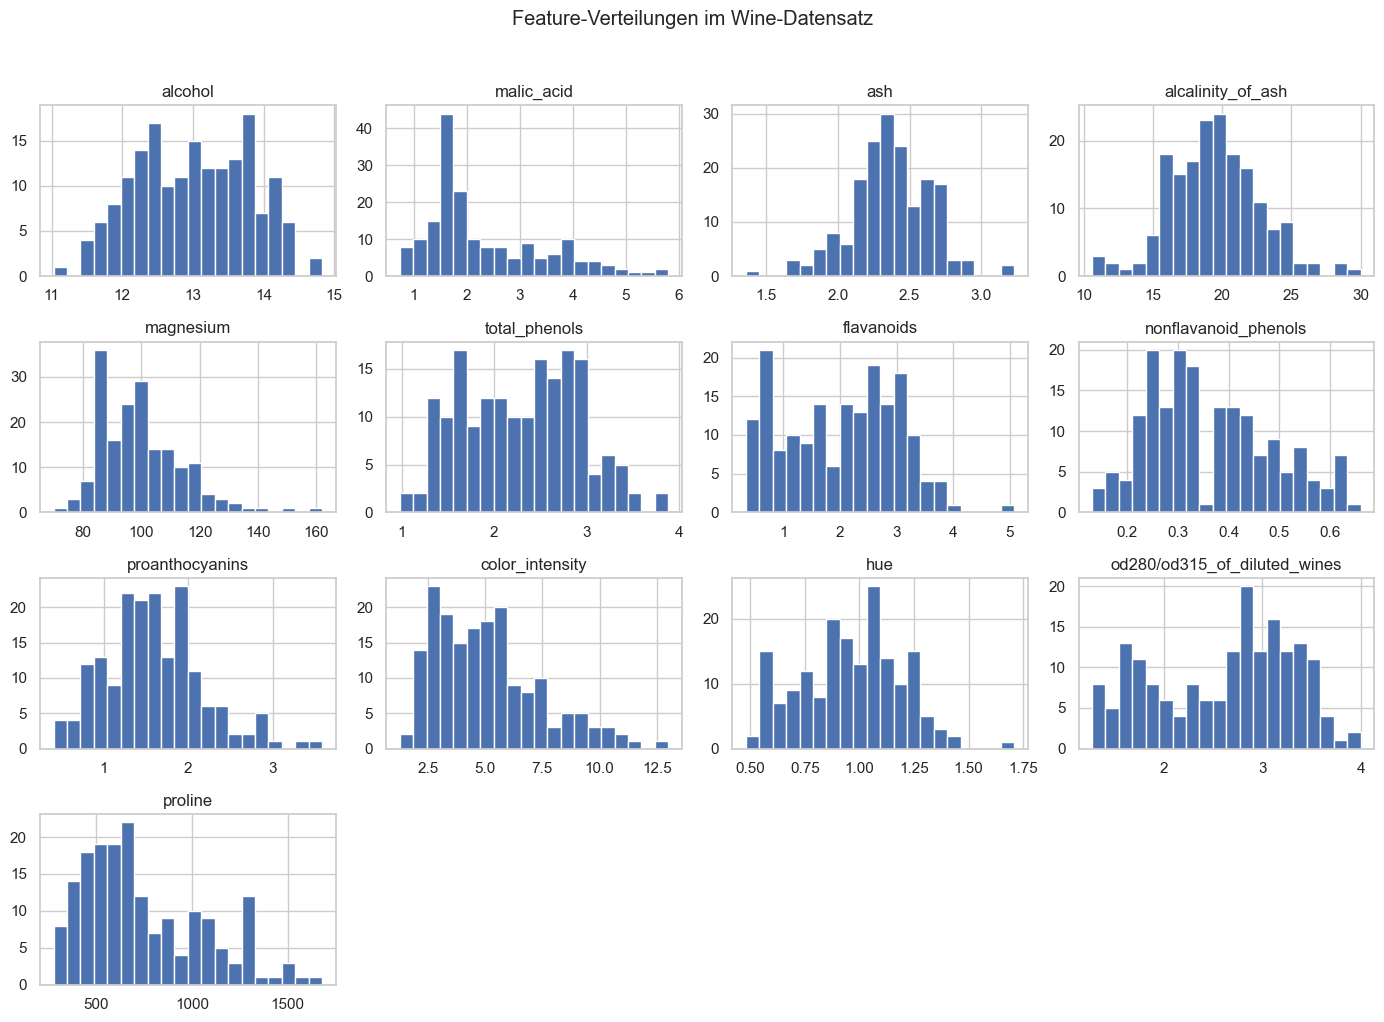

In [5]:
axes = features.hist(bins=20, figsize=(14, 10), edgecolor="white")
plt.suptitle("Feature-Verteilungen im Wine-Datensatz", y=1.02)
plt.tight_layout()
plt.show()


### 5. Feature Correlations

Die Heatmap betrachtet nur Feature-Feature-Korrelationen. Die Zielvariable bleibt bewusst außen vor, damit die explorative Sicht nicht mit der späteren Validierung vermischt wird.

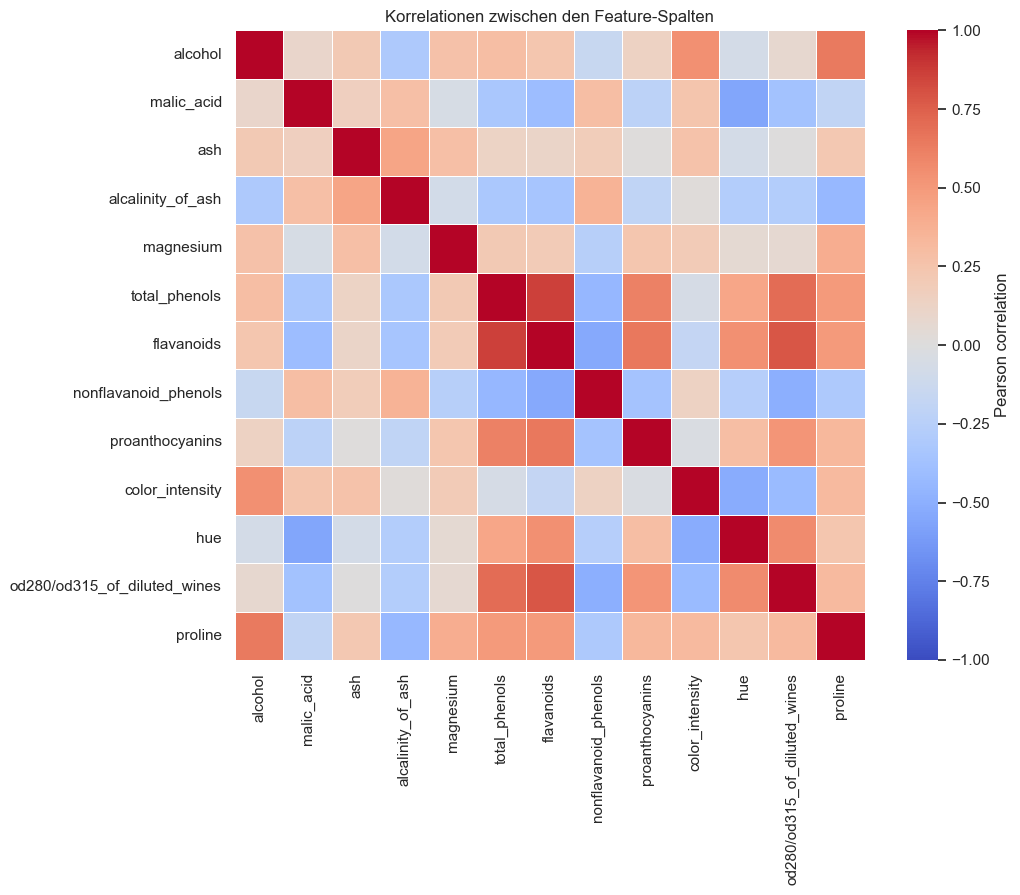

In [6]:
correlation_matrix = features.corr(method="pearson")

plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Korrelationen zwischen den Feature-Spalten")
plt.tight_layout()
plt.show()


### 6. Label View for Validation Only

Dieser Plot nutzt die bekannten Klassenlabels nur zur späteren Plausibilisierung. Er sollte nicht als Grundlage für das eigentliche Clustering verwendet werden.

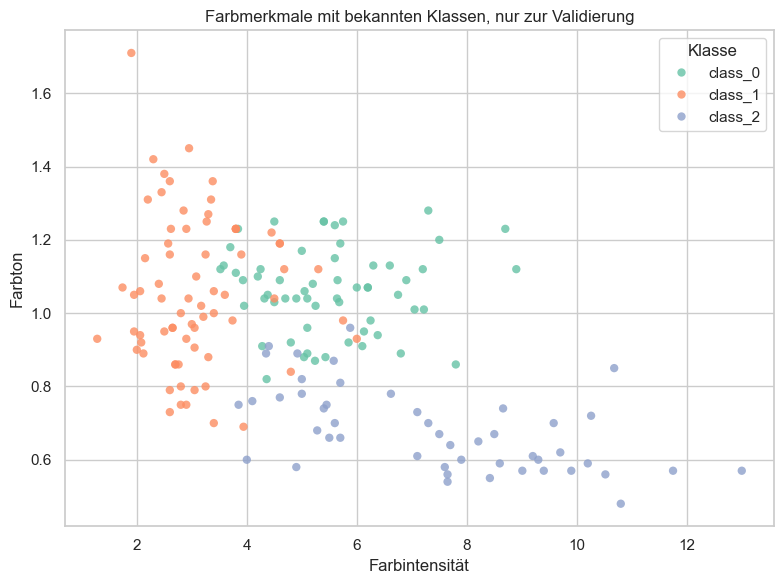

In [7]:
plot_frame = features[["color_intensity", "hue"]].copy()
plot_frame["target_name"] = target.map(target_names)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_frame,
    x="color_intensity",
    y="hue",
    hue="target_name",
    palette="Set2",
    alpha=0.8,
    edgecolor="none",
)
plt.title("Farbmerkmale mit bekannten Klassen, nur zur Validierung")
plt.xlabel("Farbintensität")
plt.ylabel("Farbton")
plt.legend(title="Klasse")
plt.tight_layout()
plt.show()


## Preprocessing

### 7. Standardize Features

Alle Clustering-Verfahren in diesem Notebook nutzen Distanzen. Ohne Skalierung würden große Wertebereiche wie `proline` die Distanz stärker dominieren als kleine Wertebereiche wie `hue`.

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_feature_frame = pd.DataFrame(scaled_features, columns=features.columns)
scaled_feature_frame.agg(["mean", "std"]).round(3)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003


## PCA

### 8. Explained Variance

Zuerst wird PCA mit allen möglichen Komponenten gefittet. So sieht man, wie viel Information in den ersten Komponenten steckt.

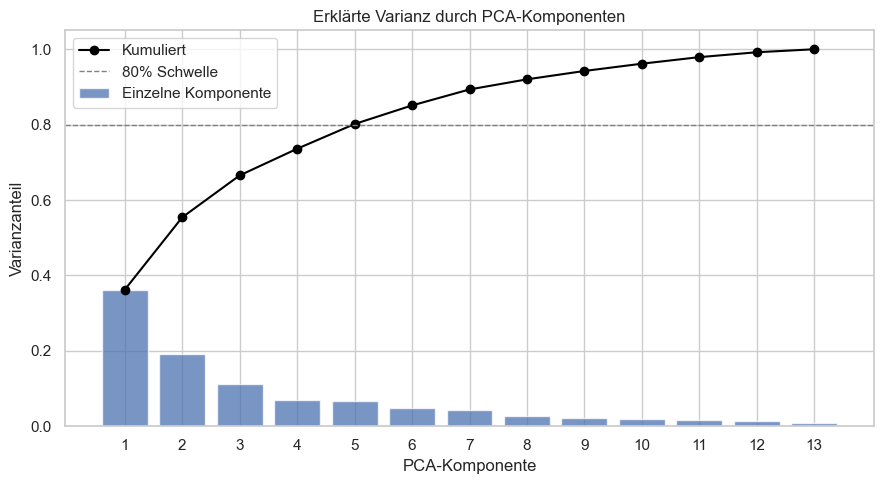

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.3620,0.3620
1,2,0.1921,0.5541
2,3,0.1112,0.6653
3,4,0.0707,0.7360
4,5,0.0656,0.8016
5,6,0.0494,0.8510


In [9]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(scaled_features)

pca_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_),
    }
)

plt.figure(figsize=(9, 5))
plt.bar(
    pca_variance["component"],
    pca_variance["explained_variance_ratio"],
    label="Einzelne Komponente",
    alpha=0.75,
)
plt.plot(
    pca_variance["component"],
    pca_variance["cumulative_explained_variance"],
    marker="o",
    color="black",
    label="Kumuliert",
)
plt.axhline(0.8, color="gray", linestyle="--", linewidth=1, label="80% Schwelle")
plt.xticks(pca_variance["component"])
plt.ylim(0, 1.05)
plt.title("Erklärte Varianz durch PCA-Komponenten")
plt.xlabel("PCA-Komponente")
plt.ylabel("Varianzanteil")
plt.legend()
plt.tight_layout()
plt.show()

pca_variance.head(6).round(4)


### 9. Two-Dimensional PCA Projection

Für die Visualisierung werden die ersten zwei Hauptkomponenten verwendet. Wichtig: Diese Projektion ist hilfreich, verliert aber fast die Hälfte der Gesamtvarianz.

Explained variance by PC1 + PC2: 0.554


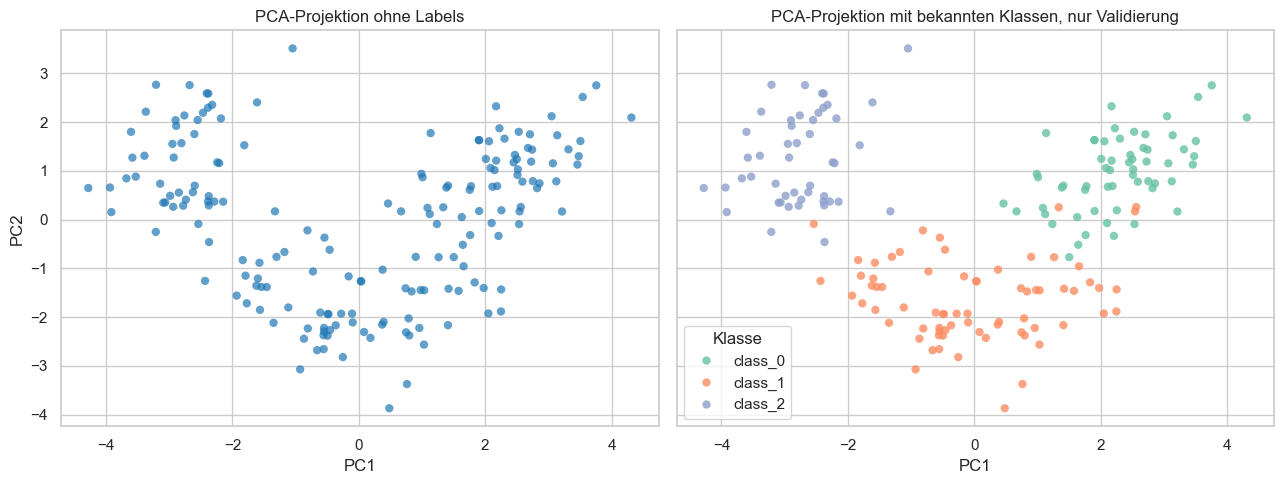

In [10]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca_2d.fit_transform(scaled_features)
pca_frame = pd.DataFrame(pca_coordinates, columns=["PC1", "PC2"])
pca_frame["target"] = target
pca_frame["target_name"] = target.map(target_names)

explained_2d = pca_2d.explained_variance_ratio_.sum()
print(f"Explained variance by PC1 + PC2: {explained_2d:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

sns.scatterplot(
    data=pca_frame,
    x="PC1",
    y="PC2",
    color="tab:blue",
    alpha=0.7,
    edgecolor="none",
    ax=axes[0],
)
axes[0].set_title("PCA-Projektion ohne Labels")

sns.scatterplot(
    data=pca_frame,
    x="PC1",
    y="PC2",
    hue="target_name",
    palette="Set2",
    alpha=0.8,
    edgecolor="none",
    ax=axes[1],
)
axes[1].set_title("PCA-Projektion mit bekannten Klassen, nur Validierung")
axes[1].legend(title="Klasse")

for axis in axes:
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")

plt.tight_layout()
plt.show()


### 10. Interpret PCA Components

Die Loadings zeigen, welche ursprünglichen Features besonders stark in PC1 und PC2 eingehen. Das hilft, die Achsen inhaltlich vorsichtig zu interpretieren.

In [11]:
pca_loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=features.columns,
    columns=["PC1", "PC2"],
)

important_loadings = pd.concat(
    [
        pca_loadings.reindex(pca_loadings["PC1"].abs().sort_values(ascending=False).head(6).index),
        pca_loadings.reindex(pca_loadings["PC2"].abs().sort_values(ascending=False).head(6).index),
    ]
).drop_duplicates()

important_loadings.round(3)


,PC1,PC2
flavanoids,0.423,-0.003
total_phenols,0.395,0.065
od280/od315_of_diluted_wines,0.376,-0.164
proanthocyanins,0.313,0.039
nonflavanoid_phenols,-0.299,0.029
hue,0.297,-0.279
color_intensity,-0.089,0.530
alcohol,0.144,0.484
proline,0.287,0.365
ash,-0.002,0.316


## kMeans Clustering

### 11. Choose `k` with Elbow and Silhouette

Da die bekannte Klassenanzahl nicht als Trainingsinformation verwendet werden soll, wird `k` zuerst über interne Kriterien geprüft. Der Elbow-Plot betrachtet die Inertia, der Silhouette-Score bewertet die Trennung der Cluster.

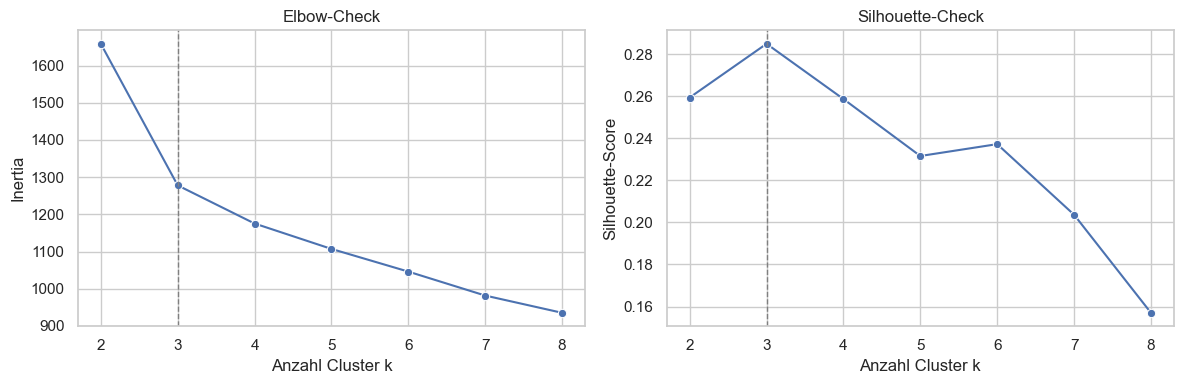

,k,inertia,silhouette
0,2,1658.759,0.259
1,3,1277.928,0.285
2,4,1175.352,0.259
3,5,1107.007,0.232
4,6,1046.002,0.237
5,7,981.595,0.204
6,8,935.201,0.157


In [12]:
k_selection_rows = []

for number_of_clusters in range(2, 9):
    kmeans_model = KMeans(
        n_clusters=number_of_clusters,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )
    cluster_labels = kmeans_model.fit_predict(scaled_features)
    k_selection_rows.append(
        {
            "k": number_of_clusters,
            "inertia": kmeans_model.inertia_,
            "silhouette": silhouette_score(scaled_features, cluster_labels),
        }
    )

k_selection = pd.DataFrame(k_selection_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=k_selection, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].axvline(3, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Elbow-Check")
axes[0].set_xlabel("Anzahl Cluster k")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=k_selection, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].axvline(3, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Silhouette-Check")
axes[1].set_xlabel("Anzahl Cluster k")
axes[1].set_ylabel("Silhouette-Score")

plt.tight_layout()
plt.show()

k_selection.round(3)


### 12. Helper Functions for Evaluation

Die Clusterqualität wird zuerst intern über Silhouette gemessen. Danach wird optional gegen die bekannten Klassen validiert. Dafür eignen sich ARI und NMI, weil Cluster-IDs beliebig benannt sind.

In [13]:
def evaluate_clustering(feature_matrix, cluster_labels, known_target, label_name):
    unique_clusters = set(cluster_labels)
    non_noise_mask = cluster_labels != -1
    number_of_clusters = len(unique_clusters - {-1})
    noise_points = int((cluster_labels == -1).sum())

    if number_of_clusters >= 2 and non_noise_mask.sum() > number_of_clusters:
        silhouette = silhouette_score(feature_matrix[non_noise_mask], cluster_labels[non_noise_mask])
    else:
        silhouette = np.nan

    return {
        "method": label_name,
        "clusters": number_of_clusters,
        "noise_points": noise_points,
        "silhouette_without_noise": silhouette,
        "ARI_vs_target": adjusted_rand_score(known_target, cluster_labels),
        "NMI_vs_target": normalized_mutual_info_score(known_target, cluster_labels),
    }


def cluster_crosstab(cluster_labels, known_target):
    table = pd.crosstab(
        pd.Series(known_target, name="known_target"),
        pd.Series(cluster_labels, name="cluster"),
    )
    table.index = [target_names[index] for index in table.index]
    return table


### 13. kMeans on All Scaled Features

Das ist methodisch sauberer als nur auf der 2D-PCA-Projektion zu fitten, weil alle 13 skalierten Features verwendet werden.

In [14]:
kmeans_scaled = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)
kmeans_scaled_labels = kmeans_scaled.fit_predict(scaled_features)

kmeans_scaled_result = evaluate_clustering(
    scaled_features,
    kmeans_scaled_labels,
    target,
    "kMeans, 13 scaled features",
)

pd.DataFrame([kmeans_scaled_result]).round(3)


,method,clusters,noise_points,silhouette_without_noise,ARI_vs_target,NMI_vs_target
0,"kMeans, 13 scaled features",3,0,0.285,0.897,0.876


In [15]:
cluster_crosstab(kmeans_scaled_labels, target)


cluster,0,1,2
class_0,0,0,59
class_1,65,3,3
class_2,0,48,0


### 14. kMeans on 2D PCA Coordinates

Dieses Modell ist besonders anschaulich, weil Training und Darstellung beide in derselben zweidimensionalen Projektion stattfinden. Der Preis ist Informationsverlust.

In [16]:
kmeans_pca = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)
kmeans_pca_labels = kmeans_pca.fit_predict(pca_coordinates)

kmeans_pca_result = evaluate_clustering(
    pca_coordinates,
    kmeans_pca_labels,
    target,
    "kMeans, 2D PCA",
)

pd.DataFrame([kmeans_pca_result]).round(3)


,method,clusters,noise_points,silhouette_without_noise,ARI_vs_target,NMI_vs_target
0,"kMeans, 2D PCA",3,0,0.561,0.895,0.882


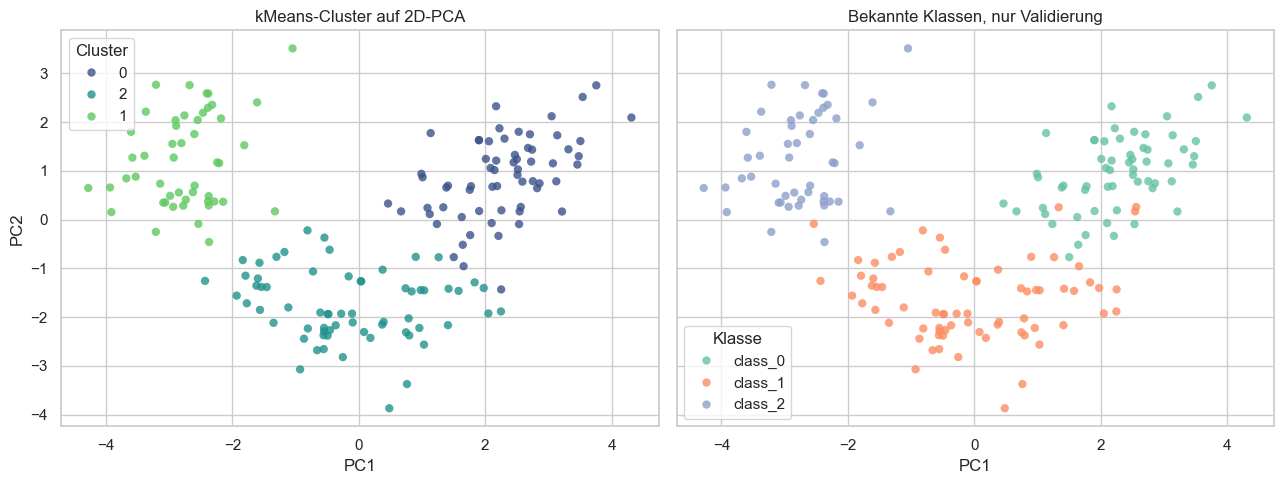

cluster,0,1,2
class_0,59,0,0
class_1,5,1,65
class_2,0,48,0


In [17]:
visualization_frame = pca_frame.copy()
visualization_frame["kmeans_pca_cluster"] = kmeans_pca_labels.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

sns.scatterplot(
    data=visualization_frame,
    x="PC1",
    y="PC2",
    hue="kmeans_pca_cluster",
    palette="viridis",
    alpha=0.8,
    edgecolor="none",
    ax=axes[0],
)
axes[0].set_title("kMeans-Cluster auf 2D-PCA")
axes[0].legend(title="Cluster")

sns.scatterplot(
    data=visualization_frame,
    x="PC1",
    y="PC2",
    hue="target_name",
    palette="Set2",
    alpha=0.8,
    edgecolor="none",
    ax=axes[1],
)
axes[1].set_title("Bekannte Klassen, nur Validierung")
axes[1].legend(title="Klasse")

for axis in axes:
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")

plt.tight_layout()
plt.show()

cluster_crosstab(kmeans_pca_labels, target)


## Hierarchical Clustering

### 15. Dendrogram and Agglomerative Clustering

Das Dendrogramm ist nützlich, um grob zu sehen, ob größere Gruppenstrukturen entstehen. Hier wird Ward-Linkage auf den skalierten Features verwendet.

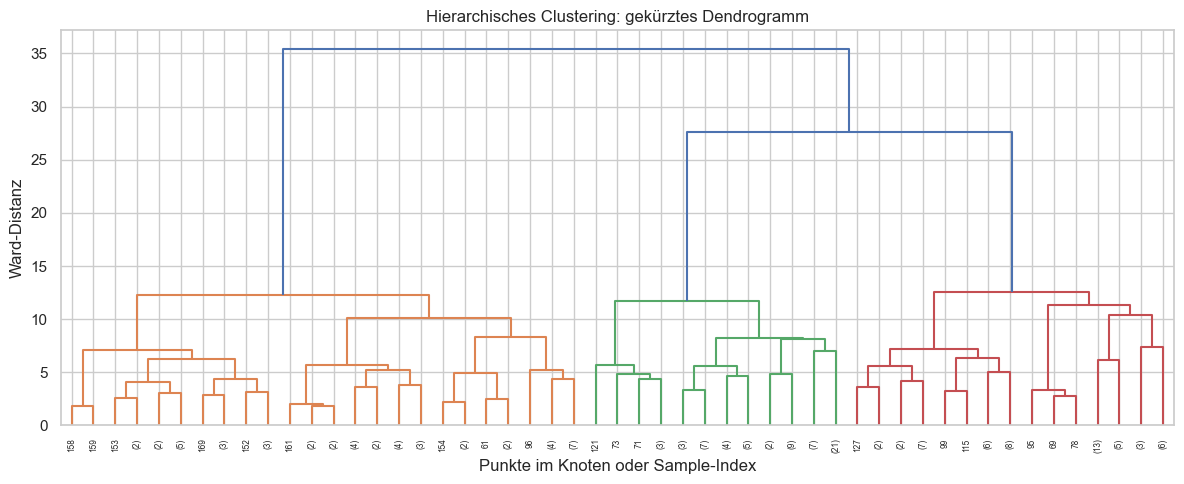

,method,clusters,noise_points,silhouette_without_noise,ARI_vs_target,NMI_vs_target
0,"Agglomerative, 13 scaled features",3,0,0.277,0.79,0.786


In [18]:
linkage_matrix = linkage(scaled_features, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.title("Hierarchisches Clustering: gekürztes Dendrogramm")
plt.xlabel("Punkte im Knoten oder Sample-Index")
plt.ylabel("Ward-Distanz")
plt.tight_layout()
plt.show()

agglomerative_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
agglomerative_labels = agglomerative_model.fit_predict(scaled_features)

agglomerative_result = evaluate_clustering(
    scaled_features,
    agglomerative_labels,
    target,
    "Agglomerative, 13 scaled features",
)

pd.DataFrame([agglomerative_result]).round(3)


In [19]:
cluster_crosstab(agglomerative_labels, target)


cluster,0,1,2
class_0,0,0,59
class_1,58,8,5
class_2,0,48,0


## DBSCAN

### 16. Inspect Neighborhood Distances

DBSCAN benötigt insbesondere `eps`. Eine einfache Orientierung ist die sortierte Distanz zum fünftnächsten Nachbarn, weil hier `min_samples=5` verwendet wird.

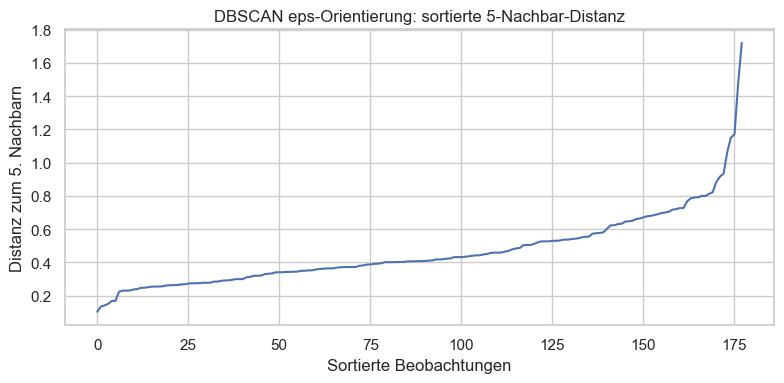

In [20]:
min_samples = 5
nearest_neighbors = NearestNeighbors(n_neighbors=min_samples)
nearest_neighbors.fit(pca_coordinates)
neighbor_distances, _ = nearest_neighbors.kneighbors(pca_coordinates)
k_distance = np.sort(neighbor_distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distance)
plt.title("DBSCAN eps-Orientierung: sortierte 5-Nachbar-Distanz")
plt.xlabel("Sortierte Beobachtungen")
plt.ylabel("Distanz zum 5. Nachbarn")
plt.tight_layout()
plt.show()


### 17. Sweep DBSCAN Parameters

DBSCAN wird auf der 2D-PCA-Projektion getestet, weil das Ergebnis dann direkt visualisierbar ist. Der Sweep zeigt, dass die Methode für diesen Datensatz schwieriger zu parametrisieren ist als kMeans.

In [21]:
dbscan_rows = []

eps_values = np.round(np.arange(0.35, 1.06, 0.05), 2)
for eps in eps_values:
    dbscan_model = DBSCAN(eps=float(eps), min_samples=min_samples)
    dbscan_labels = dbscan_model.fit_predict(pca_coordinates)
    dbscan_rows.append(
        evaluate_clustering(
            pca_coordinates,
            dbscan_labels,
            target,
            f"DBSCAN eps={eps:.2f}",
        )
    )

dbscan_results = pd.DataFrame(dbscan_rows)
dbscan_results.sort_values(
    ["clusters", "noise_points", "silhouette_without_noise"],
    ascending=[False, True, False],
).round(3)


,method,clusters,noise_points,silhouette_without_noise,ARI_vs_target,NMI_vs_target
1,DBSCAN eps=0.40,9,60,0.498,0.240,0.457
0,DBSCAN eps=0.35,8,89,0.582,0.129,0.403
2,DBSCAN eps=0.45,6,44,0.534,0.383,0.506
3,DBSCAN eps=0.50,5,31,0.523,0.379,0.500
4,DBSCAN eps=0.55,3,23,0.570,0.528,0.579
9,DBSCAN eps=0.80,2,5,0.478,0.438,0.549
7,DBSCAN eps=0.70,2,6,0.480,0.437,0.543
8,DBSCAN eps=0.75,2,6,0.480,0.437,0.543
6,DBSCAN eps=0.65,2,8,0.481,0.424,0.521
5,DBSCAN eps=0.60,2,16,0.499,0.431,0.526


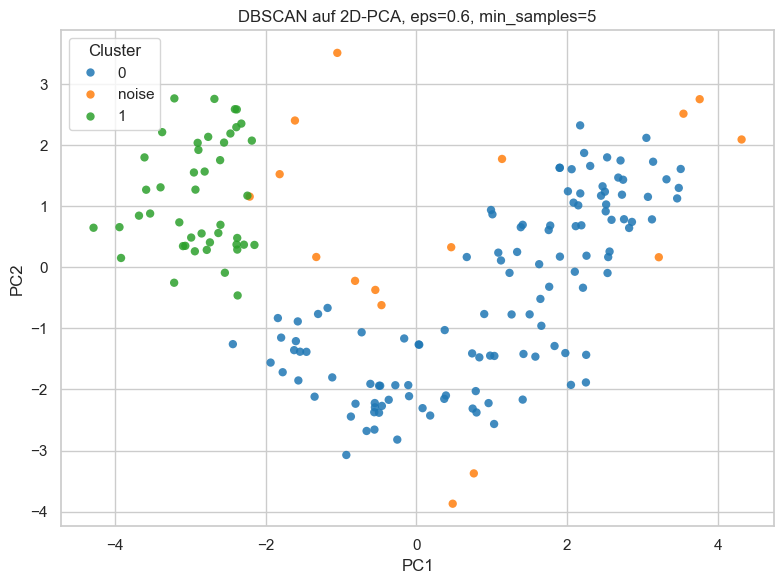

,method,clusters,noise_points,silhouette_without_noise,ARI_vs_target,NMI_vs_target
0,"DBSCAN, eps=0.60",2,16,0.499,0.431,0.526


In [22]:
# Ein Beispielwert aus dem Sweep: sichtbar mehrere Gruppen, aber weiterhin Noise und schlechtere Zielübereinstimmung.
chosen_eps = 0.60
dbscan_example = DBSCAN(eps=chosen_eps, min_samples=min_samples)
dbscan_labels = dbscan_example.fit_predict(pca_coordinates)

dbscan_visualization_frame = pca_frame.copy()
dbscan_visualization_frame["dbscan_cluster"] = pd.Series(dbscan_labels).astype(str)
dbscan_visualization_frame["dbscan_cluster"] = dbscan_visualization_frame["dbscan_cluster"].replace({"-1": "noise"})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=dbscan_visualization_frame,
    x="PC1",
    y="PC2",
    hue="dbscan_cluster",
    palette="tab10",
    alpha=0.85,
    edgecolor="none",
)
plt.title(f"DBSCAN auf 2D-PCA, eps={chosen_eps}, min_samples={min_samples}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

pd.DataFrame([
    evaluate_clustering(pca_coordinates, dbscan_labels, target, f"DBSCAN, eps={chosen_eps:.2f}")
]).round(3)


## Results

### 18. Compare Methods

Die Tabelle vergleicht interne Clusterqualität und externe Validierung gegen die bekannten Klassen. ARI und NMI werden nur genutzt, weil dieser Beispieldatensatz Labels mitbringt; in echten Clustering-Projekten fehlen solche Labels oft.

In [23]:
model_comparison = pd.DataFrame(
    [
        kmeans_scaled_result,
        kmeans_pca_result,
        agglomerative_result,
        evaluate_clustering(pca_coordinates, dbscan_labels, target, f"DBSCAN, eps={chosen_eps:.2f}"),
    ]
)

model_comparison.round(3)


,method,clusters,noise_points,silhouette_without_noise,ARI_vs_target,NMI_vs_target
0,"kMeans, 13 scaled features",3,0,0.285,0.897,0.876
1,"kMeans, 2D PCA",3,0,0.561,0.895,0.882
2,"Agglomerative, 13 scaled features",3,0,0.277,0.790,0.786
3,"DBSCAN, eps=0.60",2,16,0.499,0.431,0.526


## Takeaways

- Die Aufgabenstellung ist mit diesem Datensatz gut erfüllbar, weil die Daten numerisch, vollständig und clusterbar sind.
- Die Zielspalte sollte beim Clustering nicht in die Feature-Matrix gelangen. Sie ist nur für die nachträgliche Kontrolle sinnvoll.
- Skalierung ist ein notwendiger Schritt, weil die Merkmale stark unterschiedliche Größenordnungen haben.
- PCA hilft sehr bei der Visualisierung, erklärt mit zwei Komponenten aber nur einen Teil der Datenstruktur. Deshalb ist kMeans auf allen skalierten Features methodisch die sauberere Hauptvariante.
- kMeans mit `k=3` ist hier plausibel: Die interne Struktur spricht dafür und die externe Prüfung gegen die bekannten Klassen zeigt hohe Übereinstimmung.
- DBSCAN ist ein gutes Gegenbeispiel: Die Methode ist nicht falsch, aber für diese Daten und diese Projektion schwerer zu parametrisieren und liefert weniger stabile drei Gruppen.
- Für dein eigenes Notebook wäre die wichtigste Änderung, `target` konsequent separat zu halten und die Wahl der Clusteranzahl sowie die Qualität der Cluster mit Kennzahlen zu begründen.